In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print ("imported")

imported


In [2]:
df = pd.read_csv('water_pollution_disease.csv')
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())
df.info()



Dataset Shape: 3000 rows and 24 columns


,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,7.89,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,14.68,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,9.96,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,6.77,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,12.51,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Country                                        3000 non-null   object 
 1   Region                                         3000 non-null   object 
 2   Year                                           3000 non-null   int64  
 3   Water Source Type                              3000 non-null   object 
 4   Contaminant Level (ppm)                        3000 non-null   float64
 5   pH Level                                       3000 non-null   float64
 6   Turbidity (NTU)                                3000 non-null   float64
 7   Dissolved Oxygen (mg/L)                        3000 non-null   float64
 8   Nitrate Level (mg/L)                           3000 non-null   float64
 9   Lead Concentration (µg/L)                      3000 

In [3]:
name_corrections = {
    'Lead Concentration (ТЕg/L)': 'Lead Concentration (µg/L)',
    'Temperature (ТАC)': 'Temperature (°C)',
    'Population Density (people per kmТВ)': 'Population Density (people per km²)'
}
df.rename(columns=name_corrections, inplace=True)
print("1. Column names successfully repaired.")
df['Water Treatment Method'] = df['Water Treatment Method'].fillna('Unknown')

df.info()

1. Column names successfully repaired.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Country                                        3000 non-null   object 
 1   Region                                         3000 non-null   object 
 2   Year                                           3000 non-null   int64  
 3   Water Source Type                              3000 non-null   object 
 4   Contaminant Level (ppm)                        3000 non-null   float64
 5   pH Level                                       3000 non-null   float64
 6   Turbidity (NTU)                                3000 non-null   float64
 7   Dissolved Oxygen (mg/L)                        3000 non-null   float64
 8   Nitrate Level (mg/L)                           3000 non-null   float64
 9   Lead Concentr

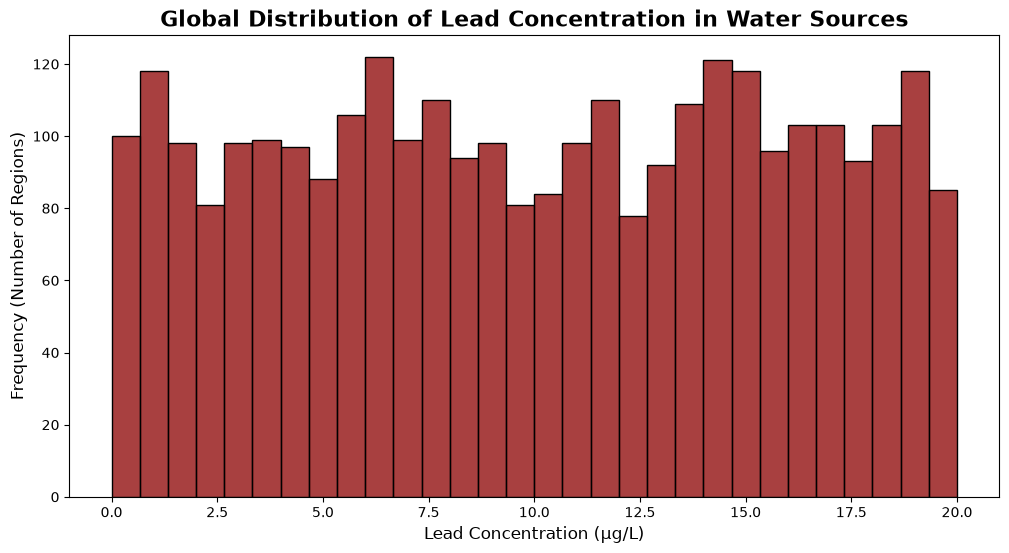

count    3000.000000
mean       10.047913
std         5.798238
min         0.000000
25%         5.120000
50%        10.065000
75%        15.032500
max        20.000000
Name: Lead Concentration (µg/L), dtype: float64


In [4]:
 
plt.figure(figsize=(12, 6))
sns.histplot(df['Lead Concentration (µg/L)'], bins=30,color='darkred')
plt.title('Global Distribution of Lead Concentration in Water Sources', fontsize=16, fontweight='bold')
plt.xlabel('Lead Concentration (µg/L)', fontsize=12)
plt.ylabel('Frequency (Number of Regions)', fontsize=12)
plt.show()
print(df['Lead Concentration (µg/L)'].describe())

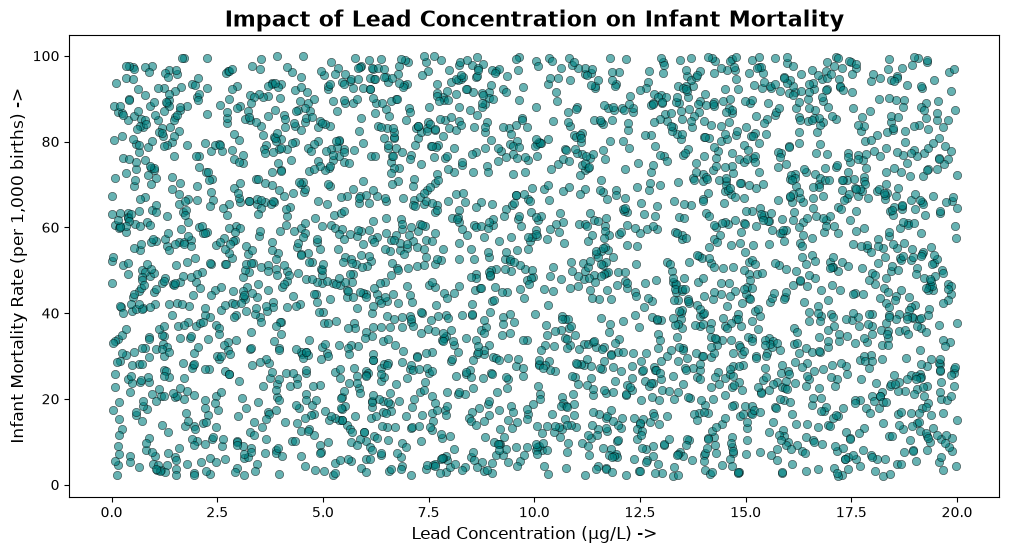


--- Mathematical Correlation Score ---
Score: -0.01


In [5]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Lead Concentration (µg/L)', y='Infant Mortality Rate (per 1,000 live births)', 
                alpha=0.6, color='teal', edgecolor='black')
plt.title('Impact of Lead Concentration on Infant Mortality', fontsize=16, fontweight='bold')
plt.xlabel('Lead Concentration (µg/L) ->', fontsize=12)
plt.ylabel('Infant Mortality Rate (per 1,000 births) ->', fontsize=12)
plt.show()
correlation = df['Lead Concentration (µg/L)'].corr(df['Infant Mortality Rate (per 1,000 live births)'])
print(f"\n--- Mathematical Correlation Score ---")
print(f"Score: {correlation:.2f}")

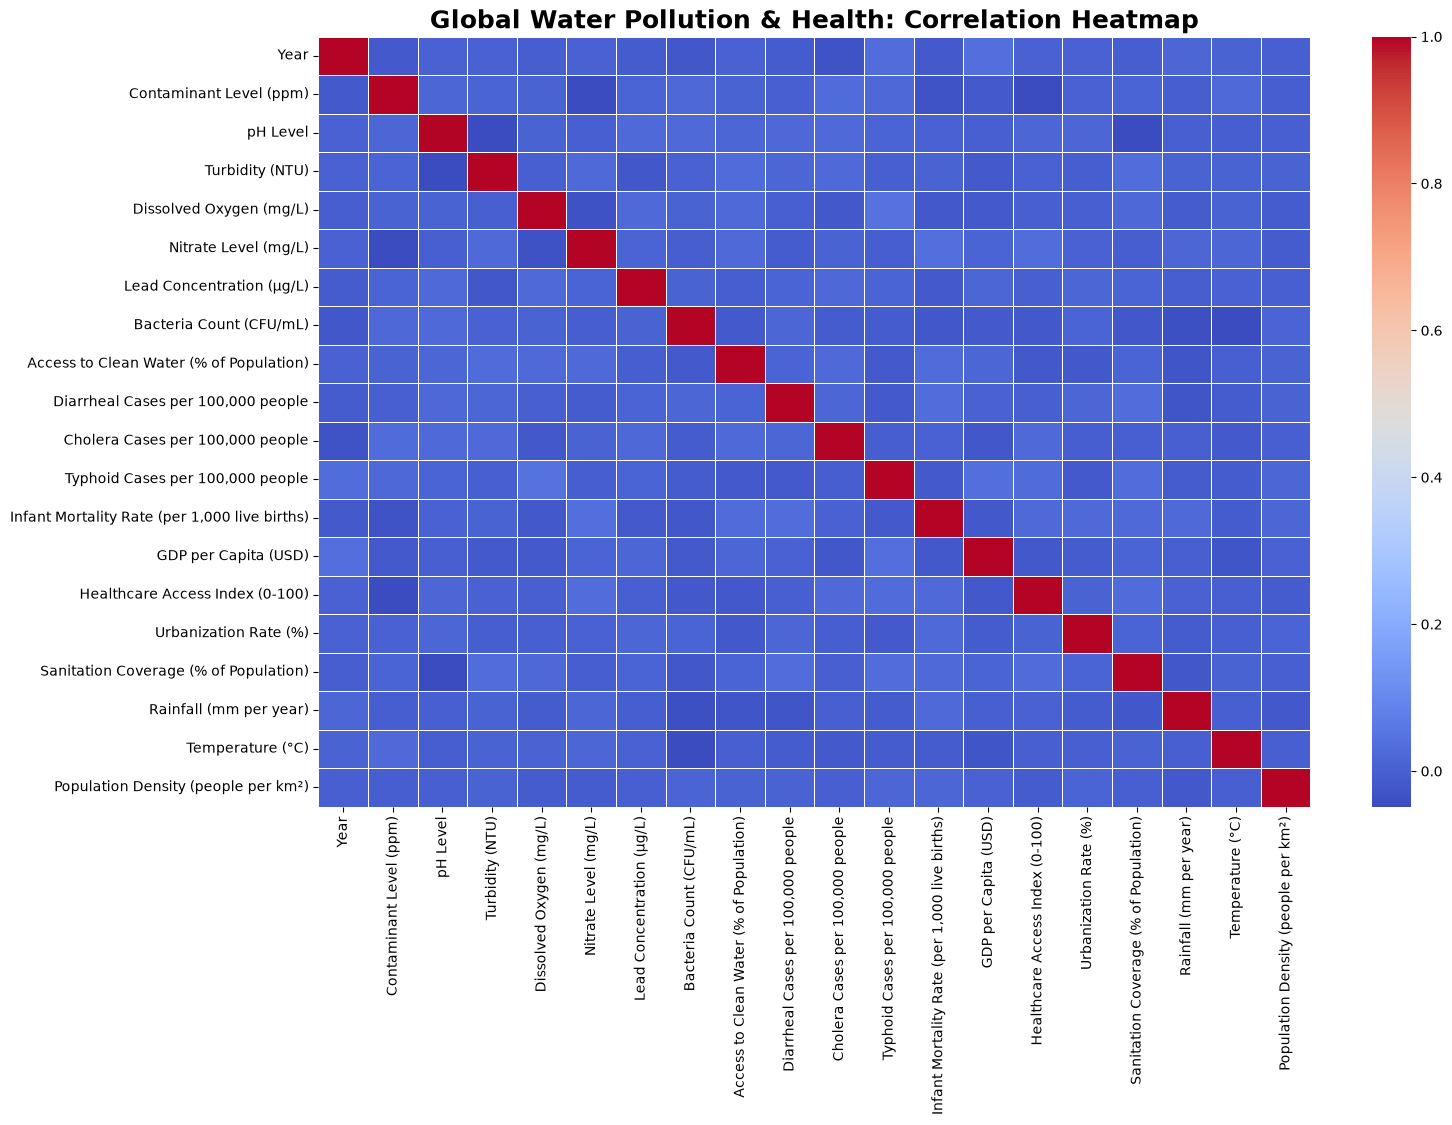


 Top Connections to Infant Mortality 
Infant Mortality Rate (per 1,000 live births)    1.000000
Nitrate Level (mg/L)                             0.037444
Diarrheal Cases per 100,000 people               0.031683
Access to Clean Water (% of Population)          0.027276
Sanitation Coverage (% of Population)            0.024856
Name: Infant Mortality Rate (per 1,000 live births), dtype: float64


In [6]:
plt.figure(figsize=(16, 10))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Global Water Pollution & Health: Correlation Heatmap', fontsize=18, fontweight='bold')
plt.show()
print("\n Top Connections to Infant Mortality ")
print(corr_matrix['Infant Mortality Rate (per 1,000 live births)'].sort_values(ascending=False).head(5))

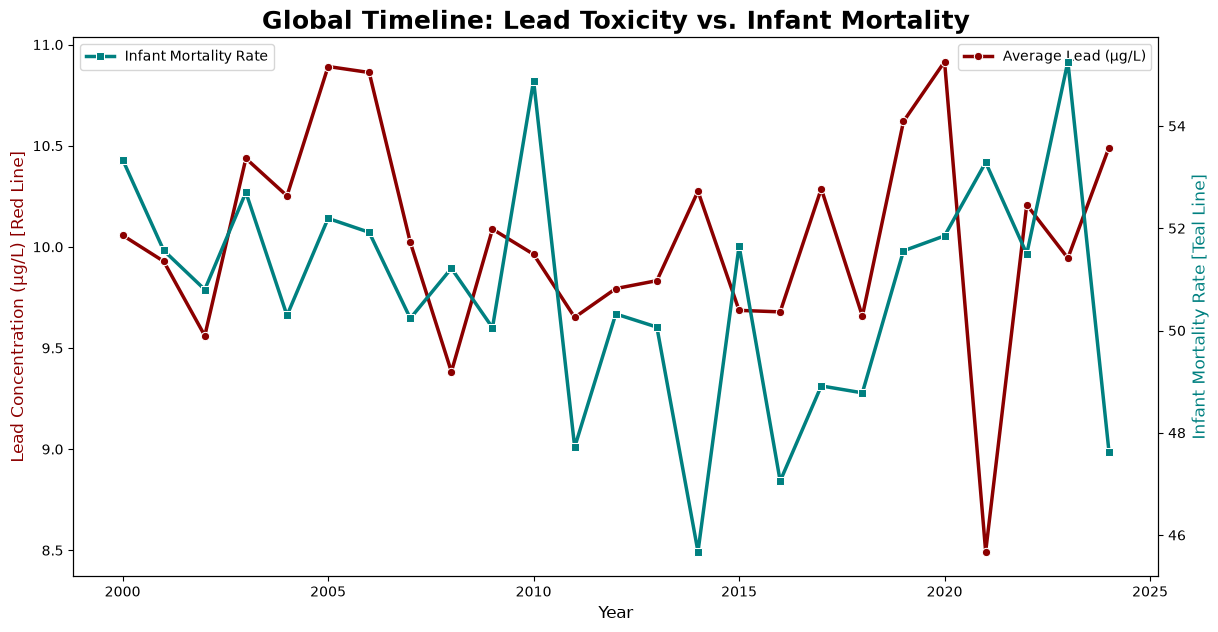


--- Time-Series Summary ---
    Year  Lead Concentration (µg/L)  \
0   2000                  10.057391   
24  2024                  10.491048   

    Infant Mortality Rate (per 1,000 live births)  
0                                       53.344000  
24                                      47.633145  


In [7]:

fig, ax1 = plt.subplots(figsize=(14, 7))
time_data = df.groupby('Year')[['Lead Concentration (µg/L)', 'Infant Mortality Rate (per 1,000 live births)']].mean().reset_index()
sns.lineplot(data=time_data, x='Year', y='Lead Concentration (µg/L)', 
             marker='o', color='darkred', linewidth=2.5, ax=ax1, label='Average Lead (µg/L)')
ax2 = ax1.twinx()
sns.lineplot(data=time_data, x='Year', y='Infant Mortality Rate (per 1,000 live births)', 
             marker='s', color='teal', linewidth=2.5, ax=ax2, label='Infant Mortality Rate')
plt.title('Global Timeline: Lead Toxicity vs. Infant Mortality', fontsize=18, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Lead Concentration (µg/L) [Red Line]', fontsize=12, color='darkred')
ax2.set_ylabel('Infant Mortality Rate [Teal Line]', fontsize=12, color='teal')
plt.show()
print("\n--- Time-Series Summary ---")
print(time_data.iloc[[0, -1]])

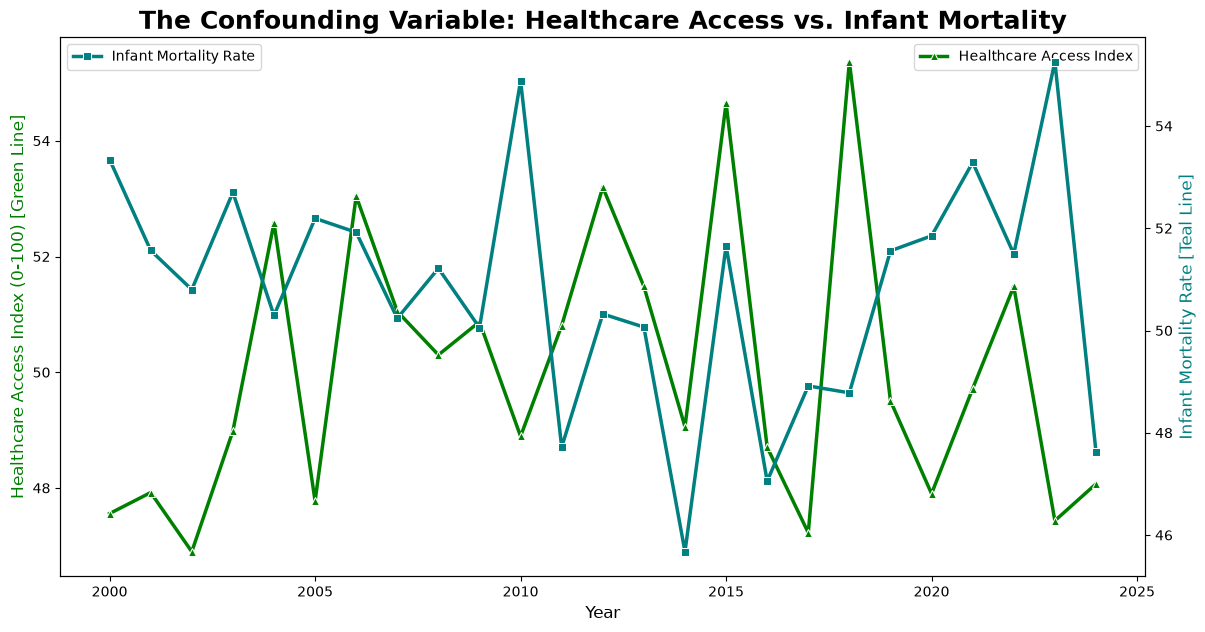


--- The Final Proof: Healthcare vs. Mortality ---
    Year  Healthcare Access Index (0-100)  \
0   2000                        47.558348   
24  2024                        48.070484   

    Infant Mortality Rate (per 1,000 live births)  
0                                       53.344000  
24                                      47.633145  


In [8]:

fig, ax1 = plt.subplots(figsize=(14, 7))
healthcare_data = df.groupby('Year')[['Healthcare Access Index (0-100)', 'Infant Mortality Rate (per 1,000 live births)']].mean().reset_index()
sns.lineplot(data=healthcare_data, x='Year', y='Healthcare Access Index (0-100)', 
             marker='^', color='green', linewidth=2.5, ax=ax1, label='Healthcare Access Index')
ax2 = ax1.twinx()
sns.lineplot(data=healthcare_data, x='Year', y='Infant Mortality Rate (per 1,000 live births)', 
             marker='s', color='teal', linewidth=2.5, ax=ax2, label='Infant Mortality Rate')
plt.title('The Confounding Variable: Healthcare Access vs. Infant Mortality', fontsize=18, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Healthcare Access Index (0-100) [Green Line]', fontsize=12, color='green')
ax2.set_ylabel('Infant Mortality Rate [Teal Line]', fontsize=12, color='teal')
plt.show()
print("\n--- The Final Proof: Healthcare vs. Mortality ---")
print(healthcare_data.iloc[[0, -1]])

In [9]:

df.to_csv('cleaned_water_pollution_data.csv', index=False)
print("Clean data saved successfully!")

Clean data saved successfully!
